In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

### 1) Data Preperation

In [72]:
covertype = fetch_ucirepo(id=31) 
X = covertype.data.features 
y = covertype.data.targets 

X['cover_type'] = y

print(X.info())
print(y.info())

print(y.value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Soil_Type1                          581012 non-null  int64
 12 

In [73]:
# select only cover types 1 and 2 for binary classification
df = X.loc[X['cover_type'].isin([1, 2])].copy()

In [74]:
df

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4,cover_type
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
5,2579,132,6,300,-15,67,230,237,140,6031,...,0,0,0,0,0,0,0,0,0,2
11,2886,151,11,371,26,5253,234,240,136,4051,...,0,0,0,0,0,0,0,0,0,2
12,2742,134,22,150,69,3215,248,224,92,6091,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
576882,2617,29,13,390,128,2081,215,211,130,592,...,0,0,0,0,0,0,0,1,0,2
576883,2614,21,13,379,125,2051,211,212,135,618,...,0,0,0,0,0,0,0,1,0,2
576884,2612,17,13,371,123,2021,208,211,138,644,...,0,0,0,0,0,0,0,1,0,2
576885,2610,16,14,365,110,1991,208,211,138,671,...,0,0,0,0,0,0,0,1,0,2


In [94]:
df.shape

(495141, 56)

In [75]:
df['target'] = [1 if x == 1 else 0 for x in df['cover_type']]

In [76]:
X = df.drop(columns=['cover_type', 'target'])
y = df['target']

#spliting the data into training and test sets 
X_train , X_test, y_train, y_test = tts(X,y, test_size = 0.2, random_state= 42)

In [95]:
print(f'training data : {X_train.shape}')
print(f'test set : {X_test.shape}')

training data : (396112, 54)
test set : (99029, 54)


In [77]:
# standardizing the features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 2) Perceptron Classifier

In [78]:
class PerceptronModel:
    def __init__(self, learning_rate = 0.01, n_iter = 100):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.weights = None
        self.bias = None
        self.activation_function = self._step_function

    
    def fit(self, X, y):

        if not isinstance(X, np.ndarray):
            X = X.to_numpy()

        if not isinstance(y, np.ndarray):
            y = y.to_numpy()

        # get feature information
        n_samples, n_features = X.shape 

        #initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # training the model
        for _ in range(self.n_iter):

            errors = 0
            for idx, x_i in enumerate(X):

                #finding linear output
                linear_output = np.dot(x_i, self.weights) + self.bias

                #apply step function
                y_hat = self.activation_function(linear_output)

                if y_hat != y[idx]:

                    #update weights and bias
                    self.weights = self.weights + self.learning_rate * (y[idx] - y_hat)* x_i
                    self.bias = self.bias + self.learning_rate * (y[idx] - y_hat)

                    errors += 1

            print(f"Iteration {_+1}/{self.n_iter}, Errors: {errors}")
            if errors == 0:
                break
        
    def predict(self,X):
        if not isinstance(X,np.ndarray):
            X= X.to_numpy()

        linear_output = np.dot(X, self.weights) + self.bias

        #y_hat is a vector
        y_hat = self.activation_function(linear_output)
        return y_hat

    def _step_function(self, x):

        # np.where function works even if x is a single value or an array. 
        return np.where(x >= 0, 1, 0) 
    


In [79]:
perceptron = PerceptronModel(learning_rate = 0.01 , n_iter = 100)
perceptron.fit(X_train_scaled, y_train)

y_pred = perceptron.predict(X_test_scaled)

Iteration 1/100, Errors: 123572
Iteration 2/100, Errors: 123420
Iteration 3/100, Errors: 123296
Iteration 4/100, Errors: 123568
Iteration 5/100, Errors: 123718
Iteration 6/100, Errors: 123258
Iteration 7/100, Errors: 123225
Iteration 8/100, Errors: 123449
Iteration 9/100, Errors: 123492
Iteration 10/100, Errors: 123605
Iteration 11/100, Errors: 123663
Iteration 12/100, Errors: 123573
Iteration 13/100, Errors: 123374
Iteration 14/100, Errors: 123399
Iteration 15/100, Errors: 123334
Iteration 16/100, Errors: 123790
Iteration 17/100, Errors: 123512
Iteration 18/100, Errors: 123496
Iteration 19/100, Errors: 123235
Iteration 20/100, Errors: 123354
Iteration 21/100, Errors: 123698
Iteration 22/100, Errors: 123373
Iteration 23/100, Errors: 123622
Iteration 24/100, Errors: 123551
Iteration 25/100, Errors: 123537
Iteration 26/100, Errors: 123499
Iteration 27/100, Errors: 123550
Iteration 28/100, Errors: 123730
Iteration 29/100, Errors: 123474
Iteration 30/100, Errors: 123326
Iteration 31/100, E

In [80]:
#creating confusion matrix
confusion_matrix_per = pd.crosstab(y_test, y_pred, rownames= ['Actual'], colnames = ['Predicted'])
print(confusion_matrix_per)

accuracy_per = (confusion_matrix_per[0][0] + confusion_matrix_per[1][1]) / confusion_matrix_per.sum().sum()
precision_per = (confusion_matrix_per[1][1]) / (confusion_matrix_per[1][1] + confusion_matrix_per[1][0])
recall_per = confusion_matrix_per[1][1] / (confusion_matrix_per[1][1] + confusion_matrix_per[0][1])
f1_per = (2 * precision_per * recall_per) / (precision_per + recall_per)

print(f"Accuracy: {accuracy_per:.4f}")
print(f"Precision: {precision_per:.4f}")
print(f"Recall: {recall_per:.4f}")
print(f"F1 Score: {f1_per:.4f}")


Predicted      0      1
Actual                 
0          45918  10641
1          15845  26625
Accuracy: 0.7325
Precision: 0.7145
Recall: 0.6269
F1 Score: 0.6678


Visualising Decision boundary

In [81]:
X_train

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Wilderness_Area2,Wilderness_Area3,Wilderness_Area4
84079,2991,90,1,277,19,3220,221,236,151,6117,...,0,0,0,0,0,0,0,0,0,0
316955,2887,64,29,134,74,134,232,169,50,1054,...,0,0,0,0,0,0,0,0,0,0
184275,3039,96,2,212,37,3069,223,236,149,514,...,0,0,0,0,0,0,0,0,0,0
404753,3118,63,7,335,59,1890,227,225,132,3350,...,0,0,0,0,0,0,0,0,1,0
520810,3187,127,20,700,-19,1458,248,223,94,2656,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
305950,2963,280,9,150,33,2683,194,241,187,470,...,0,0,0,0,0,0,0,0,1,0
431716,3049,244,16,120,19,3129,186,251,201,871,...,0,0,0,0,0,0,0,0,1,0
143635,3140,4,9,283,58,5030,208,222,151,446,...,0,0,0,0,0,0,0,0,0,0
158576,2939,88,12,30,3,3625,238,220,110,2656,...,0,0,0,0,0,0,0,0,0,0


In [82]:
#take 2 features and train the model again

X_train_2d = X_train[['Elevation', 'Aspect']]
X_test_2d = X_test[['Elevation', 'Aspect']]

y_train_2d = y_train
y_test_2d = y_test


X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_test_2d_scaled = scaler.transform(X_test_2d)

In [83]:
perceptron_2d = PerceptronModel(learning_rate = 0.01 , n_iter = 100)
perceptron_2d.fit(X_train_2d_scaled, y_train_2d)

y_hat_2d = perceptron_2d.predict(X_test_2d_scaled)

Iteration 1/100, Errors: 139139
Iteration 2/100, Errors: 139186
Iteration 3/100, Errors: 139108
Iteration 4/100, Errors: 139082
Iteration 5/100, Errors: 139170
Iteration 6/100, Errors: 139082
Iteration 7/100, Errors: 139170
Iteration 8/100, Errors: 139082
Iteration 9/100, Errors: 139170
Iteration 10/100, Errors: 139082
Iteration 11/100, Errors: 139170
Iteration 12/100, Errors: 139082
Iteration 13/100, Errors: 139170
Iteration 14/100, Errors: 139082
Iteration 15/100, Errors: 139170
Iteration 16/100, Errors: 139082
Iteration 17/100, Errors: 139170
Iteration 18/100, Errors: 139082
Iteration 19/100, Errors: 139170
Iteration 20/100, Errors: 139082
Iteration 21/100, Errors: 139170
Iteration 22/100, Errors: 139082
Iteration 23/100, Errors: 139170
Iteration 24/100, Errors: 139082
Iteration 25/100, Errors: 139170
Iteration 26/100, Errors: 139082
Iteration 27/100, Errors: 139170
Iteration 28/100, Errors: 139082
Iteration 29/100, Errors: 139170
Iteration 30/100, Errors: 139082
Iteration 31/100, E

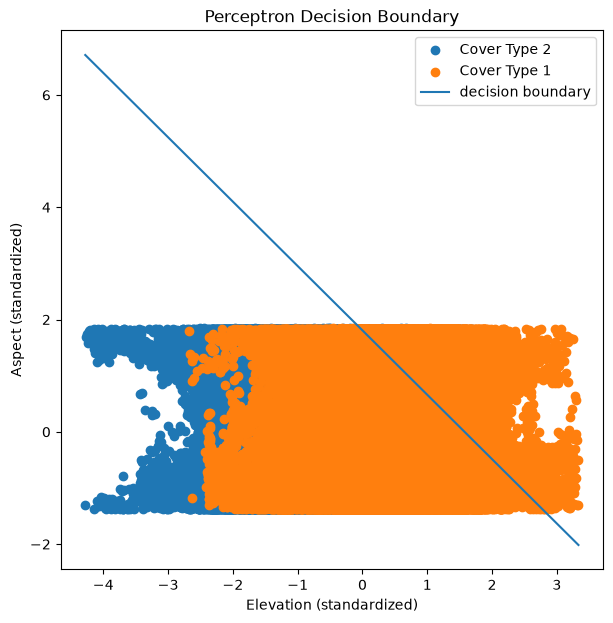

In [84]:
w1, w2 = perceptron_2d.weights
bias = perceptron_2d.bias

# z =  w1*x1 + w2*x2 + bias. The decision boundary is where z = 0, so we can solve for x2 in terms of x1:


#linspace() creates equally spaced values between arg 1 and arg 2. 
x_values = np.linspace(X_train_2d_scaled[:, 0].min(), X_train_2d_scaled[:, 0].max(), 100)
y_values = -(w1 * x_values + bias) / w2


plt.figure(figsize=(7,7))

plt.scatter(
    X_train_2d_scaled[y_train == 0, 0],
    X_train_2d_scaled[y_train == 0, 1],
    label = "Cover Type 2"
)

plt.scatter(
    X_train_2d_scaled[y_train == 1, 0],
    X_train_2d_scaled[y_train == 1, 1],
    label = "Cover Type 1"
)

plt.plot(x_values,y_values , label = 'decision boundary')

plt.xlabel('Elevation (standardized)')
plt.ylabel('Aspect (standardized)')
plt.title('Perceptron Decision Boundary')
plt.legend()
plt.show()

### 3) Logistic Regression

In [85]:
class LogisticRegression:
    def __init__(self, learning_rate = 0.01, n_iters = 100 , threshold = 0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.weights = None
        self.bias = 0
        self.activation_function = self._sigmoid_func
        self.loss_function = self.BCE
        self.cost_history = []

    def fit(self, X, y):
        if not isinstance(X, np.ndarray):
            X = X.to_numpy()

        if not isinstance(y,np.ndarray):
            y = y.to_numpy()
        
        n_samples, n_features = X.shape

        # initializing weights
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):

            z = np.dot(X , self.weights) + self.bias
            #where y_hat is probability and not prediction
            y_hat = self.activation_function(z)

            # to ensure log(0) does not occur
            y_hat = np.clip(y_hat , 1e-15 , 1 - 1e-15)

            #gradients -> calculating by minimising the loss function
            dw = (1/n_samples) * np.dot(X.T , (y_hat - y))
            db = (1/n_samples) * np.sum(y_hat - y)

            #updating weights 
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db 

            self.cost_history.append(self.loss_function(y , y_hat))

            print(f"Ireation {_+1}, Error {self.cost_history[-1]}")
   
    def predict(self, X):
        if not isinstance(X , np.ndarray):
            X = X.to_numpy()

        z = np.dot(X , self.weights) + self.bias
        y_prob = self.activation_function(z)
        y_pred = np.where(y_prob >= self.threshold, 1 ,0)
        return y_pred, y_prob
        
    def BCE(self,y, y_hat):
        if not isinstance(y , np.ndarray):
            y = y.to_numpy()
            
        m = len(y)
        return -(1/m) * np.sum(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

    def _sigmoid_func(self, X):
        return  1 / ( 1 + np.exp(-1* X))


In [86]:
lgr = LogisticRegression(learning_rate= 0.01 , n_iters = 500)

lgr.fit(X_train_scaled, y_train)
y_pred , y_prob = lgr.predict(X_test_scaled)

Ireation 1, Error 0.6931471805599452
Ireation 2, Error 0.6918777287543527
Ireation 3, Error 0.6906192832328454
Ireation 4, Error 0.6893717391762746
Ireation 5, Error 0.6881349924709558
Ireation 6, Error 0.6869089397171455
Ireation 7, Error 0.6856934782369958
Ireation 8, Error 0.6844885060819962
Ireation 9, Error 0.6832939220399122
Ireation 10, Error 0.6821096256412331
Ireation 11, Error 0.6809355171651368
Ireation 12, Error 0.6797714976449829
Ireation 13, Error 0.6786174688733504
Ireation 14, Error 0.6774733334066192
Ireation 15, Error 0.6763389945691218
Ireation 16, Error 0.6752143564568616
Ireation 17, Error 0.6740993239408211
Ireation 18, Error 0.6729938026698621
Ireation 19, Error 0.6718976990732369
Ireation 20, Error 0.6708109203627134
Ireation 21, Error 0.6697333745343352
Ireation 22, Error 0.6686649703698188
Ireation 23, Error 0.6676056174376033
Ireation 24, Error 0.6665552260935659
Ireation 25, Error 0.6655137074814076
Ireation 26, Error 0.6644809735327273
Ireation 27, Error 0.

In [87]:
confusion_matrix_lgr = pd.crosstab(y_test , y_pred , rownames= ['Actual'] , colnames = ['Predicted'])

print(confusion_matrix_lgr)

accuracy_lgr = (confusion_matrix_lgr[0][0] + confusion_matrix_lgr[1][1]) / confusion_matrix_lgr.sum().sum()
precision_lgr = (confusion_matrix_lgr[1][1]) / (confusion_matrix_lgr[1][1] + confusion_matrix_lgr[1][0])
recall_lgr = confusion_matrix_lgr[1][1] / (confusion_matrix_lgr[1][1] + confusion_matrix_lgr[0][1])
f1_lgr = (2 * precision_lgr *recall_lgr) / (precision_lgr + recall_lgr)

print(f"Accuracy: {accuracy_lgr:.4f}")
print(f"Precision: {precision_lgr:.4f}")
print(f"Recall: {recall_lgr:.4f}")
print(f"F1 Score: {f1_lgr:.4f}")


Predicted      0      1
Actual                 
0          46107  10452
1          13024  29446
Accuracy: 0.7629
Precision: 0.7380
Recall: 0.6933
F1 Score: 0.7150


In [88]:
lgr_2d = LogisticRegression(learning_rate=0.01, n_iters=500)
lgr_2d.fit(X_train_2d_scaled, y_train)

Ireation 1, Error 0.6931471805599452
Ireation 2, Error 0.6924665596556134
Ireation 3, Error 0.6917893582749896
Ireation 4, Error 0.6911155590699689
Ireation 5, Error 0.6904451447456731
Ireation 6, Error 0.6897780980609856
Ireation 7, Error 0.6891144018290732
Ireation 8, Error 0.6884540389178951
Ireation 9, Error 0.6877969922506986
Ireation 10, Error 0.6871432448065017
Ireation 11, Error 0.6864927796205657
Ireation 12, Error 0.6858455797848513
Ireation 13, Error 0.6852016284484661
Ireation 14, Error 0.684560908818097
Ireation 15, Error 0.6839234041584319
Ireation 16, Error 0.6832890977925691
Ireation 17, Error 0.6826579731024142
Ireation 18, Error 0.6820300135290657
Ireation 19, Error 0.6814052025731887
Ireation 20, Error 0.6807835237953763
Ireation 21, Error 0.6801649608165009
Ireation 22, Error 0.6795494973180526
Ireation 23, Error 0.6789371170424664
Ireation 24, Error 0.6783278037934403
Ireation 25, Error 0.6777215414362389
Ireation 26, Error 0.6771183138979887
Ireation 27, Error 0.6

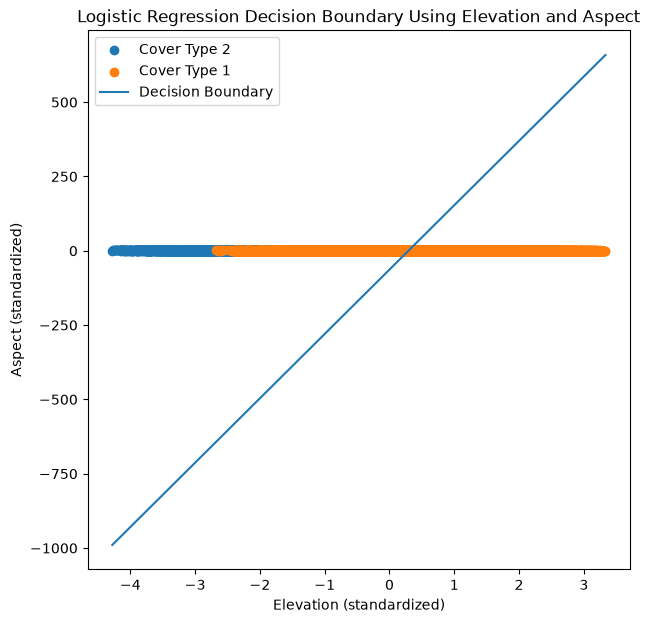

In [89]:
w1 , w2 = lgr_2d.weights
b = lgr_2d.bias

x1 = np.linspace(
    X_train_2d_scaled[:, 0].min(),
    X_train_2d_scaled[:, 0].max(),
    100
)

x2 = -(w1 * x1 + b) / w2

plt.figure(figsize=(7, 7))

plt.scatter(
    X_train_2d_scaled[y_train.to_numpy() == 0, 0],
    X_train_2d_scaled[y_train.to_numpy() == 0, 1],
    label='Cover Type 2'
)

plt.scatter(
    X_train_2d_scaled[y_train.to_numpy() == 1, 0],
    X_train_2d_scaled[y_train.to_numpy() == 1, 1],
    label='Cover Type 1'
)


plt.plot(
    x1,
    x2,
    label='Decision Boundary'
)

plt.xlabel('Elevation (standardized)')
plt.ylabel('Aspect (standardized)')
plt.title('Logistic Regression Decision Boundary Using Elevation and Aspect')
plt.legend()
plt.show()

In [90]:
print(lgr_2d.weights)
print(lgr_2d.bias)

[ 0.74554906 -0.0034422 ]
-0.21780716237862952


### 4) Binary Cross-Entropy

In [91]:
test_bce = lgr.BCE(y_test, y_prob)
print(test_bce)

0.5200601582066099


Test BCE Loss: 0.5201


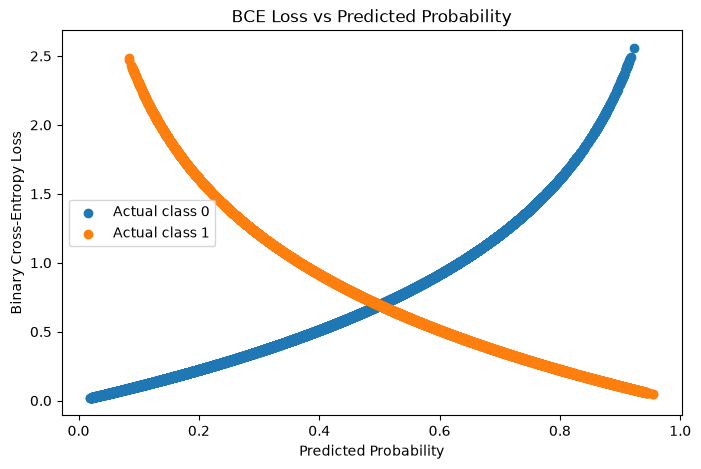

In [92]:
# Convert y_test to NumPy array
y_test_array = y_test

# Calculate the overall BCE loss on the test set
test_bce = lgr.BCE(y_test_array, y_prob)

print(f"Test BCE Loss: {test_bce:.4f}")


# Calculate BCE loss for each individual test observation
individual_bce = -(
    y_test_array * np.log(y_prob) +
    (1 - y_test_array) * np.log(1 - y_prob)
)


# Plot BCE loss as a function of predicted probability
plt.figure(figsize=(8, 5))

plt.scatter(
    y_prob[y_test_array == 0],
    individual_bce[y_test_array == 0],
    label='Actual class 0'
)

plt.scatter(
    y_prob[y_test_array == 1],
    individual_bce[y_test_array == 1],
    label='Actual class 1'
)

plt.xlabel('Predicted Probability')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('BCE Loss vs Predicted Probability')
plt.legend()
plt.show()

### 5) Table comparison

In [93]:
comparison_table = pd.DataFrame({
    'Model': ['Perceptron', 'Logistic Regression'],
    'Accuracy': [accuracy_per, accuracy_lgr],
    'Precision': [precision_per, precision_lgr],
    'Recall': [recall_per, recall_lgr],
    'F1 Score': [f1_per, f1_lgr]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Perceptron,0.732543,0.714458,0.626913,0.667829
1,Logistic Regression,0.762938,0.738032,0.693336,0.714986
